In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\credit-risk-model')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [2]:
df_raw = pd.read_csv('data/raw/data.csv')
df_raw['TransactionStartTime'] = pd.to_datetime(df_raw['TransactionStartTime'])
customer_df = pd.read_csv('data/processed/customer_features.csv')

print(f"Raw transactions: {len(df_raw):,}")
print(f"Customer features: {customer_df.shape}")
customer_df.head()

Raw transactions: 95,662
Customer features: (3742, 18)


,CustomerId,Recency,Frequency,Monetary,Avg_Amount,Std_Amount,Max_Amount,Min_Amount,Total_Value,Avg_Value,Total_Fraud,Fraud_Rate,Unique_Products,Unique_Channels,Unique_Categories,Avg_Hour,Avg_DayOfWeek,Weekend_Ratio
0,CustomerId_1,84,1,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,10000,10000.000000,0,0.0,1,1,1,16.000000,2.000000,0.000000
1,CustomerId_10,84,1,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,10000,10000.000000,0,0.0,1,1,1,16.000000,2.000000,0.000000
2,CustomerId_1001,90,5,20000.0,4000.000000,6558.963333,10000.0,-5000.0,30400,6080.000000,0,0.0,3,2,2,7.800000,4.000000,0.000000
3,CustomerId_1002,26,11,4225.0,384.090909,560.498966,1500.0,-75.0,4775,434.090909,0,0.0,3,2,2,13.454545,2.909091,0.181818
4,CustomerId_1003,12,6,20000.0,3333.333333,6030.478146,10000.0,-5000.0,32000,5333.333333,0,0.0,4,2,2,14.333333,4.000000,0.000000


In [3]:
snapshot_date = df_raw['TransactionStartTime'].max() + pd.Timedelta(days=1)

rfm = df_raw.groupby('CustomerId').agg(
    Recency=('TransactionStartTime',
             lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionId', 'count'),
    Monetary=('Amount', 'sum')
).reset_index()

print("=== RFM Summary ===")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

=== RFM Summary ===
       Recency  Frequency      Monetary
count  3742.00    3742.00  3.742000e+03
mean     31.46      25.56  1.717377e+05
std      27.12      96.93  2.717305e+06
min       1.00       1.00 -1.049000e+08
25%       6.00       2.00  4.077440e+03
50%      25.00       7.00  2.000000e+04
75%      54.00      20.00  7.996775e+04
max      91.00    4091.00  8.345124e+07


In [4]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled,
                              columns=['Recency_scaled',
                                       'Frequency_scaled',
                                       'Monetary_scaled'])
print("RFM features scaled successfully!")
print(f"Mean after scaling: {rfm_scaled_df.mean().round(3).values}")
print(f"Std after scaling:  {rfm_scaled_df.std().round(3).values}")

RFM features scaled successfully!
Mean after scaling: [ 0. -0. -0.]
Std after scaling:  [1. 1. 1.]


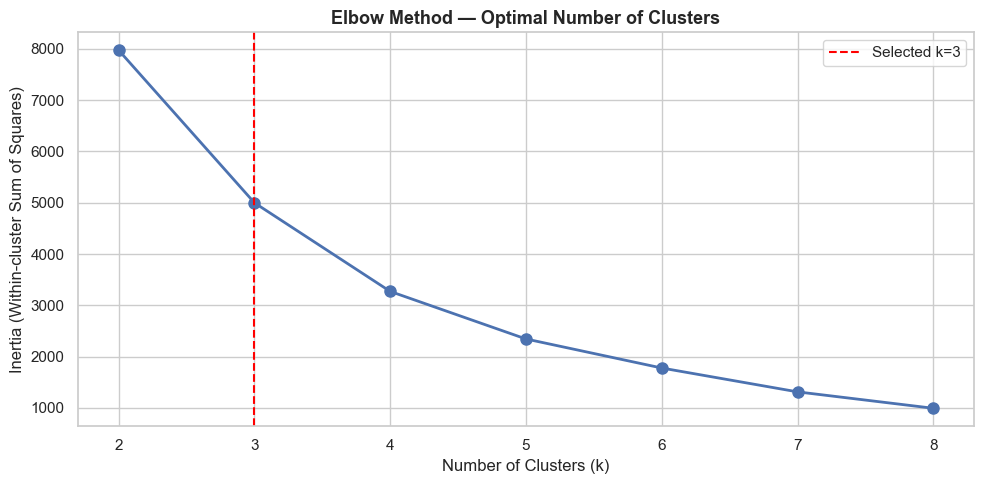

Elbow plot saved!


In [5]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5,
            label='Selected k=3')
plt.title('Elbow Method — Optimal Number of Clusters',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/plot_elbow.png', dpi=150)
plt.show()
print("Elbow plot saved!")

In [6]:
# Remove extreme outlier before clustering
rfm_clean = rfm[rfm['Frequency'] < 1000].copy()
print(f"Removed {len(rfm) - len(rfm_clean)} outlier customers")
print(f"Clustering on {len(rfm_clean)} customers")

# Scale
scaler = StandardScaler()
rfm_scaled_clean = scaler.fit_transform(
    rfm_clean[['Recency','Frequency','Monetary']]
)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled_clean)

print("\n=== Cluster Sizes ===")
print(rfm_clean['Cluster'].value_counts().sort_index())

print("\n=== Cluster Profiles (Mean RFM) ===")
cluster_profile = rfm_clean.groupby('Cluster')[
    ['Recency','Frequency','Monetary']
].mean().round(2)
print(cluster_profile)

Removed 3 outlier customers
Clustering on 3739 customers

=== Cluster Sizes ===
Cluster
0    2229
1       5
2    1505
Name: count, dtype: int64

=== Cluster Profiles (Mean RFM) ===
         Recency  Frequency     Monetary
Cluster                                 
0          11.95      34.43    178780.74
1          27.20     100.40  50697885.60
2          60.40       6.88     59327.95


In [11]:
# Manual identification based on cluster profiles:
# Cluster 2: Recency=60.4 (highest), Frequency=6.88 (lowest), 
#            Monetary=59,327 (lowest) → HIGHEST RISK
# Cluster 0: Recency=11.95 (lowest), Frequency=34.43, Monetary=178K → LOW RISK  
# Cluster 1: Only 5 customers, very high monetary → OUTLIER GROUP

print("=== Cluster Analysis ===")
print(cluster_profile)
print()
print("Interpretation:")
print("  Cluster 2 → HIGH RISK: most inactive (60 days), fewest transactions (6.88), lowest monetary")
print("  Cluster 0 → LOW RISK:  most active (12 days), moderate transactions, moderate monetary")
print("  Cluster 1 → OUTLIER:   only 5 customers, extreme monetary values")

high_risk_cluster = 2
print(f"\n✅ High-risk cluster manually set to: Cluster {high_risk_cluster}")

=== Cluster Analysis ===
         Recency  Frequency     Monetary  Risk_Score
Cluster                                             
0          11.95      34.43    178780.74         7.0
1          27.20     100.40  50697885.60         8.0
2          60.40       6.88     59327.95         3.0

Interpretation:
  Cluster 2 → HIGH RISK: most inactive (60 days), fewest transactions (6.88), lowest monetary
  Cluster 0 → LOW RISK:  most active (12 days), moderate transactions, moderate monetary
  Cluster 1 → OUTLIER:   only 5 customers, extreme monetary values

✅ High-risk cluster manually set to: Cluster 2


In [12]:
# Assign labels
rfm_clean['is_high_risk'] = (rfm_clean['Cluster'] == high_risk_cluster).astype(int)

# Add outliers back as high-risk (anomalous behavior)
outlier_ids = rfm[rfm['Frequency'] >= 1000]['CustomerId'].tolist()
print(f"Outlier customers flagged as high-risk: {outlier_ids}")

rfm_final = pd.concat([
    rfm_clean[['CustomerId','Recency','Frequency',
               'Monetary','Cluster','is_high_risk']],
    rfm[rfm['Frequency'] >= 1000][
        ['CustomerId','Recency','Frequency','Monetary']
    ].assign(Cluster=-1, is_high_risk=1)
], ignore_index=True)

print(f"\n=== is_high_risk Distribution ===")
print(rfm_final['is_high_risk'].value_counts())
print(f"\nHigh-risk customers:  {rfm_final['is_high_risk'].sum()}")
print(f"Low-risk customers:   {(rfm_final['is_high_risk']==0).sum()}")
print(f"High-risk rate:       {rfm_final['is_high_risk'].mean()*100:.1f}%")

# Merge into customer features
customer_final = customer_df.merge(
    rfm_final[['CustomerId','Cluster','is_high_risk']],
    on='CustomerId', how='left'
)
print(f"\nFinal dataset shape: {customer_final.shape}")

Outlier customers flagged as high-risk: ['CustomerId_3634', 'CustomerId_647', 'CustomerId_7343']

=== is_high_risk Distribution ===
is_high_risk
0    2234
1    1508
Name: count, dtype: int64

High-risk customers:  1508
Low-risk customers:   2234
High-risk rate:       40.3%

Final dataset shape: (3742, 20)


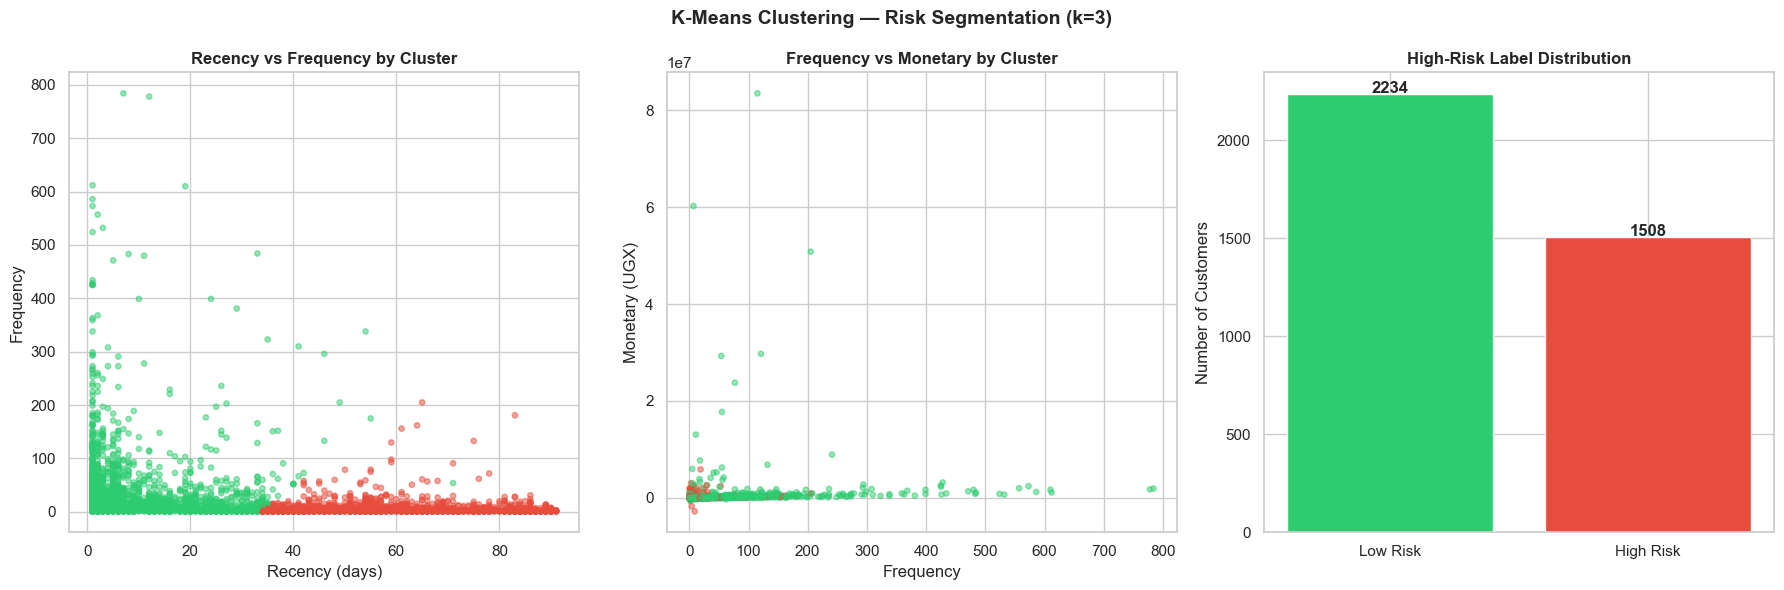

Cluster plot saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cluster_color_map = {
    c: '#e74c3c' if c == high_risk_cluster else '#2ecc71' if c != -1 else '#f39c12'
    for c in rfm_final['Cluster'].unique()
}

plot_df = rfm_final[rfm_final['Cluster'] != -1]

axes[0].scatter(plot_df['Recency'], plot_df['Frequency'],
                c=plot_df['Cluster'].map(
                    {c: '#e74c3c' if c==high_risk_cluster else '#2ecc71'
                     for c in plot_df['Cluster'].unique()}),
                alpha=0.5, s=15)
axes[0].set_title('Recency vs Frequency by Cluster', fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(plot_df['Frequency'], plot_df['Monetary'],
                c=plot_df['Cluster'].map(
                    {c: '#e74c3c' if c==high_risk_cluster else '#2ecc71'
                     for c in plot_df['Cluster'].unique()}),
                alpha=0.5, s=15)
axes[1].set_title('Frequency vs Monetary by Cluster', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (UGX)')

risk_counts = rfm_final['is_high_risk'].value_counts()
axes[2].bar(['Low Risk', 'High Risk'],
            [risk_counts.get(0,0), risk_counts.get(1,0)],
            color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[2].set_title('High-Risk Label Distribution', fontweight='bold')
axes[2].set_ylabel('Number of Customers')
for i, val in enumerate([risk_counts.get(0,0), risk_counts.get(1,0)]):
    axes[2].text(i, val+5, str(val), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('K-Means Clustering — Risk Segmentation (k=3)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot_clusters.png', dpi=150)
plt.show()
print("Cluster plot saved!")

In [14]:
customer_final.to_csv('data/processed/customer_features_labeled.csv', index=False)
print(f"✅ Saved: {customer_final.shape}")
print(f"\nClass distribution:")
print(customer_final['is_high_risk'].value_counts())
print(f"\nHigh-risk rate: {customer_final['is_high_risk'].mean()*100:.1f}%")
print(f"\nSample:")
print(customer_final[['CustomerId','Recency','Frequency','Monetary',
                        'Cluster','is_high_risk']].head(10))

✅ Saved: (3742, 20)

Class distribution:
is_high_risk
0    2234
1    1508
Name: count, dtype: int64

High-risk rate: 40.3%

Sample:
        CustomerId  Recency  Frequency  Monetary  Cluster  is_high_risk
0     CustomerId_1       84          1  -10000.0        2             1
1    CustomerId_10       84          1  -10000.0        2             1
2  CustomerId_1001       90          5   20000.0        2             1
3  CustomerId_1002       26         11    4225.0        0             0
4  CustomerId_1003       12          6   20000.0        0             0
5  CustomerId_1004       53          1    2000.0        2             1
6  CustomerId_1005       47          9   48800.0        2             1
7  CustomerId_1006       65          1    1000.0        2             1
8  CustomerId_1007       82          1   28000.0        2             1
9  CustomerId_1008       66          2   20000.0        2             1
